# 포인트 미션 상관관계 분석

**기준일 2026-08-04 · 30일 윈도우 2026-07-06 ~ 2026-08-04**

포인트는 발행 시점에 회사의 **부채**로 잡힙니다. 이 전제에서 아래 세 가지에 초점을 잡아 분석을 진행하였습니다.
**이 분석에는 임직원과 울산 스마트시티 참여자를 따로 구분해서 보진 않았으므로, 이 점에 유의해서 봐주시면 감사하겠습니다.**

1. **무분별하게 나가는 포인트가 있는가** — 발행 집중도, 소수 사용자 편중, 관리자 재량 지급
2. **없어도 되는 미션은 무엇인가** — 도달률이 0이거나, 다른 미션과 완전히 겹쳐서 빼도 잃는 사용자가 없는 미션
3. **의미가 있어 유지할 미션은 무엇인가** — 참여가 실제 앱 활동과 연결되는 미션

> **해석상 주의.** 이 분석은 특정 시점의 스냅샷 한 장을 보는 것입니다. 시간에 따라 무엇이 무엇을 바꾸었는지는 알 수 없습니다.
> "이 미션을 한 사람이 루틴도 잘 지킨다"와 "이 미션 덕분에 루틴을 잘 지키게 됐다"는 전혀 다른 이야기입니다. 원래 앱을 자주 쓰는 사람은 미션도 루틴도 다 잘하기 때문에, 순서를 거꾸로 읽을 위험이 늘 있습니다.
> 따라서 미션이 루틴 수행으로 이어지게 했다는 결론은 이 분석만으로는 한계가 있습니다.

In [74]:
import warnings
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.font_manager import FontProperties, fontManager
from scipy import stats

warnings.filterwarnings("ignore")

# ── 폰트 ────────────────────────────────────────────────────────────────────
# 플롯 안의 글자는 전부 영문으로 씁니다 (PDF 변환 시 한글 깨짐 방지).
# D2Coding 이 설치돼 있으면 fallback 으로 등록해 두어, 혹시 한글이 섞여도 렌더는 되게 합니다.
_d2 = [p for p in (Path.home() / "Library/Fonts").glob("D2Coding*.ttf")]
for _p in _d2:
    fontManager.addfont(str(_p))
if not _d2:
    raise RuntimeError("D2Coding 폰트를 찾지 못했습니다. ~/Library/Fonts 에 설치하세요. "
                       "영문 플롯 버전은 point_mission_liability.ipynb 를 쓰면 됩니다.")
# D2Coding 을 1순위로. 한글 글리프가 있어 축·범례·제목 모두 한글로 렌더됩니다.
# 없는 글리프(일부 기호)는 DejaVu Sans 로 폴백합니다.
mpl.rcParams["font.family"] = ["D2Coding", "DejaVu Sans"]
mpl.rcParams["axes.unicode_minus"] = False
mpl.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.autolayout": True,
})
# print("D2Coding 등록:", bool(_d2))

# 노트북을 repo 루트에서 열든 analysis/ 에서 열든 같은 곳을 가리키도록 위로 거슬러 찾는다.
def _find_data() -> Path:
    for base in [Path.cwd(), *Path.cwd().parents]:
        if (base / "data" / "csv" / "01_mission_catalog.csv").exists():
            return base / "data" / "csv"
    raise FileNotFoundError("data/csv 를 찾지 못했습니다. 먼저 `bash data/sql/build_all.sh` 를 실행하세요.")

DATA = _find_data()
REF_DATE, WINDOW_DAYS = "2026-08-04", 30

catalog   = pd.read_csv(DATA / "01_mission_catalog.csv")
users     = pd.read_csv(DATA / "02_user_activity_30d.csv")
earn      = pd.read_csv(DATA / "03_mission_user_earn_30d.csv")
mua       = pd.read_csv(DATA / "04_mission_user_activity_30d.csv")
liability = pd.read_csv(DATA / "06_point_liability_by_mission.csv")
monthly   = pd.read_csv(DATA / "07_mission_monthly_issue.csv", parse_dates=["month"])
audit     = pd.read_csv(DATA / "08_admin_grant_audit.csv")

# PostgreSQL COPY 는 boolean 을 't'/'f' 로 씁니다 — pandas 가 문자열로 읽으므로 되돌린다.
for _c in ["is_recipient", "meets_12w_rule", "answered_every_eligible_week",
           "under_12w_at_payout", "meets_own12_rule"]:
    audit[_c] = audit[_c].map({"t": True, "f": False})


# print({k: v.shape for k, v in
#        dict(catalog=catalog, users=users, earn=earn, mua=mua,
#             liability=liability, monthly=monthly, audit=audit).items()})

In [75]:
# ── 미션 한글 라벨 ──────────────────────────────────────────────────────────
# 플롯 축·범례에 쓸 짧은 한글 이름. 원문 설명은 표에서 그대로 씁니다.
LABEL = {
    1: "회원가입", 2: "성향문진", 3: "글쓰기(30자+)", 5: "좋아요 10개",
    6: "연속 글쓰기 3일", 7: "연속 글쓰기 5일", 8: "연속 글쓰기 7일", 9: "AI 글쓰기",
    43: "댓글 쓰기",
    10: "애드센스 연동", 11: "게임 실행", 12: "게임 랭킹 1위", 13: "게임 랭킹 2~10위",
    14: "출석 1·2·4·5일차", 15: "출석 3·6일차", 16: "출석 7일차",
    17: "글 공유 유입", 18: "유형카드 공유 유입",
    19: "첫 친구 초대", 20: "친구 초대 2~19명", 21: "친구 초대 5명", 22: "친구 초대 10·20명",
    23: "친구 초대 15명", 24: "친구 초대 21~50명", 25: "친구 초대 51~100명",
    26: "친구 초대 101~1000명",
    34: "생활문진 업데이트", 35: "첫 7일 연속 루틴(삭제됨)",
    36: "7일 연속 루틴 수행", 37: "루틴 1개 응답", 38: "식단 등록",
    39: "일일 피드백", 40: "가족 등록 수락",
    41: "12주 완주", 42: "만족도 조사",
    101: "관리자 수동 지급",
    102: "지타이 개인화 시작", 103: "지타이 기준선 생성",
    104: "기분 기록 1~6일", 105: "기분 기록 7일", 106: "기분 기록 8~13일",
    107: "기분 기록 14일", 108: "기분 기록 15일+", 109: "주간 체크업",
}

def label(no) -> str:
    if pd.isna(no):
        return "(미분류)"
    return LABEL.get(int(no), f"미션 #{int(no)}")

liability["label"] = liability.point_mission_no.map(label)
catalog["label"]   = catalog.point_mission_no.map(label)
monthly["label"]   = monthly.point_mission_no.map(label)
earn["label"]      = earn.point_mission_no.map(label)

# 색상 — 부채 관점의 의미를 담아 고정
C = {"issued": "#3b6fb6", "outstanding": "#c1443c", "used": "#7a9a4a",
     "muted": "#9aa0a6", "accent": "#d98d2b", "dark": "#2f3437"}

# 표에 찍히는 컬럼명을 한글로 바꾸는 매핑입니다.
COLS: dict[str, str] = {
    # 미션 속성
    "point_mission_no": "미션번호", "label": "미션", "mission_description": "미션 설명",
    "description": "설명", "mission_type": "유형", "category_name": "카테고리",
    "parent_category_name": "상위 카테고리", "mission_use_yn": "사용", "use_yn": "사용",
    "mission_del_yn": "삭제", "amount": "지급액", "limit_type": "제한유형",
    # 포인트 금액
    "points_issued": "누적 발행", "points_issued_30d": "30일 발행",
    "points_issued_per_user": "1인당 발행", "points_outstanding": "미상환 잔액",
    "points_used": "사용", "points_returned": "반환", "누적비중": "누적 비중",
    "points": "포인트", "points_per_earner": "적립자당 포인트",
    "points_granted": "지급액", "총_지급액": "총 지급액",
    # 사람 수
    "users": "인원", "users_all_time": "누적 인원", "earners": "적립자",
    "total_unique_users": "누적 적립자", "n_joined": "적립자",
    "n_not": "미적립자", "exclusive_earners": "전속 적립자",
    "exclusive_rate": "전속 비율", "points_per_exclusive": "전속 1인당 포인트",
    # 집중도
    "gini": "지니계수", "top10_share": "상위10% 몫", "max_user_share": "최다 1인 몫",
    # 효과 추정
    "mean_joined": "적립자 평균", "mean_not": "미적립자 평균",
    "raw_diff": "단순 차이", "p_raw": "p(단순)",
    "adj_coef": "조정 계수", "p_adj": "p(조정)",
    "cost_per_effect": "효과 1%p당 비용",
    # 감사
    "batch": "배치", "avg_weeks_answered": "평균 응답 주",
    "avg_weeks": "평균 응답 주", "n_zero_weeks": "응답 0주",
    "n_meets_rule": "12주 전부 응답", "충족": "충족 인원",
    "grant_rows": "지급 건수", "weeks_answered_12w": "응답한 주",
    "weeks_assigned_12w": "배정된 주", "own12_weeks_answered": "자기창 응답 주",
    # 기타
    "last_earn_at": "마지막 적립", "first_earn_at": "최초 적립",
}

def show(df, fmt: dict | None = None, index: bool = False):
    """컬럼명을 COLS 로 바꿔 표를 출력합니다. fmt 의 키도 같이 옮겨줍니다."""
    d = df.rename(columns=COLS)
    styler = d.style.format({COLS.get(k, k): v for k, v in (fmt or {}).items()})
    display(styler if index else styler.hide(axis="index"))

# print(f"라벨링된 미션: {len(LABEL)}개")

---
## 1. 포인트 부채 현황

발행된 포인트 중 아직 쓰이지 않은 잔액이 곧 미상환 부채입니다.

In [76]:
issued      = liability.points_issued.sum()
outstanding = liability.points_outstanding.sum()
used        = liability.points_used.sum()
returned    = liability.points_returned.sum()
issued_30d  = liability.points_issued_30d.sum()

# 30일 사용액은 liability(06) 에 없습니다. 소진된 lot 에는 사용 시점이 남지 않아서,
# 시점이 있는 chg_type='USE' 행에서만 나옵니다 — 02_user_activity_30d.csv 의 point_used_30d 가 그것입니다.
# 코호트 482명이 30일 내 포인트를 쓴 139명을 모두 포함하므로 전체 합계와 일치합니다.
used_30d    = users.point_used_30d.sum()

assert issued - used - returned == outstanding, "ledger does not reconcile"

summary = pd.DataFrame({
    "항목": ["누적 발행", "누적 사용(상환)", "반환", "미상환 잔액 (= 부채)",
            "최근 30일 발행", "최근 30일 사용"],
    "포인트": [issued, used, returned, outstanding, issued_30d, used_30d],
})
summary["총 포인트 발행량 대비"] = (summary.포인트 / issued).map("{:.1%}".format)
show(summary, {"포인트": "{:,.0f}"})

burn = issued_30d / WINDOW_DAYS
print(f"30일 평균 발행 속도 : {burn:,.0f} P/day  (연 환산 {burn*365:,.0f} P)")
print(f"상환율(사용/발행)   : {used/issued:.1%}   —  나머지 {outstanding/issued:.1%} 가 잔여 부채")

항목,포인트,총 포인트 발행량 대비
누적 발행,"8,224,195",100.0%
누적 사용(상환),"3,919,100",47.7%
반환,"91,017",1.1%
미상환 잔액 (= 부채),"4,214,078",51.2%
최근 30일 발행,"2,120,382",25.8%
최근 30일 사용,"1,915,000",23.3%


30일 평균 발행 속도 : 70,679 P/day  (연 환산 25,797,981 P)
상환율(사용/발행)   : 47.7%   —  나머지 51.2% 가 잔여 부채


**표 읽는 법.** 지금까지 발행한 822만P 중 절반이 조금 넘는 **421만P가 아직 쓰이지 않고 남아
있습니다.** 이것이 언제든 상품으로 바뀔 수 있는, 회사가 지고 있는 빚입니다.

최근 30일만 떼어 보면 발행 212만P에 사용 192만P로, 한 달 사이 **빚이 약 20만P 늘었습니다.**
발행과 사용이 얼추 비슷해 보이지만, 사용 쪽은 오래전에 쌓인 포인트를 쓴 것이고 발행 쪽은 새로 생긴
빚이라 성격이 다릅니다. 이 격차가 계속 벌어지는지가 앞으로 지켜볼 지점입니다.

또 최근 30일 발행 212만P는 누적 발행의 26%입니다. 1년 넘게 쌓인 총액의 1/4이 최근 한 달에
몰려 있다는 뜻입니다.

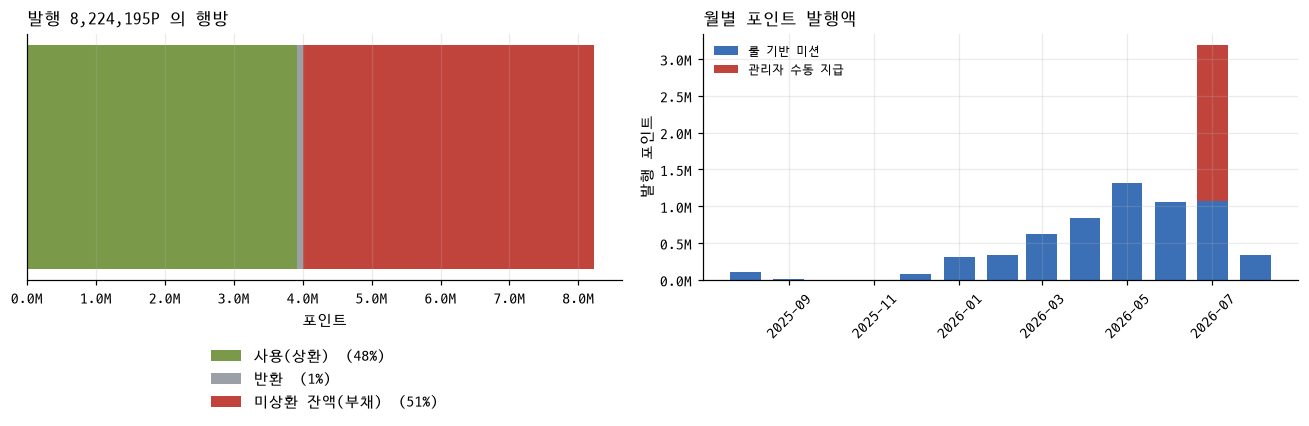

In [77]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

# (a) 발행액의 행방
ax = axes[0]
parts = [("사용(상환)", used, C["used"]), ("반환", returned, C["muted"]),
         ("미상환 잔액(부채)", outstanding, C["outstanding"])]
left = 0
for name, val, col in parts:
    ax.barh([0], [val], left=left, color=col, label=f"{name}  ({val/issued:.0%})", height=0.5)
    left += val
ax.set_yticks([])
ax.set_xlabel("포인트")
ax.set_title(f"발행 {issued:,.0f}P 의 행방", loc="left", fontsize=11)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.22), ncol=1, frameon=False)
ax.xaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda v, _: f"{v/1e6:.1f}M"))

# (b) 월별 발행 추이 — 재량 지급과 룰 기반 미션을 분리해서 쌓는다
ax = axes[1]
monthly["is_admin"] = monthly.point_mission_no == 101
mth = (monthly.pivot_table(index="month", columns="is_admin",
                           values="points_issued", aggfunc="sum")
       .reindex(columns=[False, True]).fillna(0))
ax.bar(mth.index, mth[False], width=22, color=C["issued"], label="룰 기반 미션")
ax.bar(mth.index, mth[True], width=22, bottom=mth[False],
       color=C["outstanding"], label="관리자 수동 지급")
ax.set_title("월별 포인트 발행액", loc="left", fontsize=11)
ax.set_ylabel("발행 포인트")
ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda v, _: f"{v/1e6:.1f}M"))
ax.tick_params(axis="x", rotation=45)
ax.legend(frameon=False, fontsize=8, loc="upper left")
plt.show()

### 1.1 어떤 미션이 부채를 만드는가

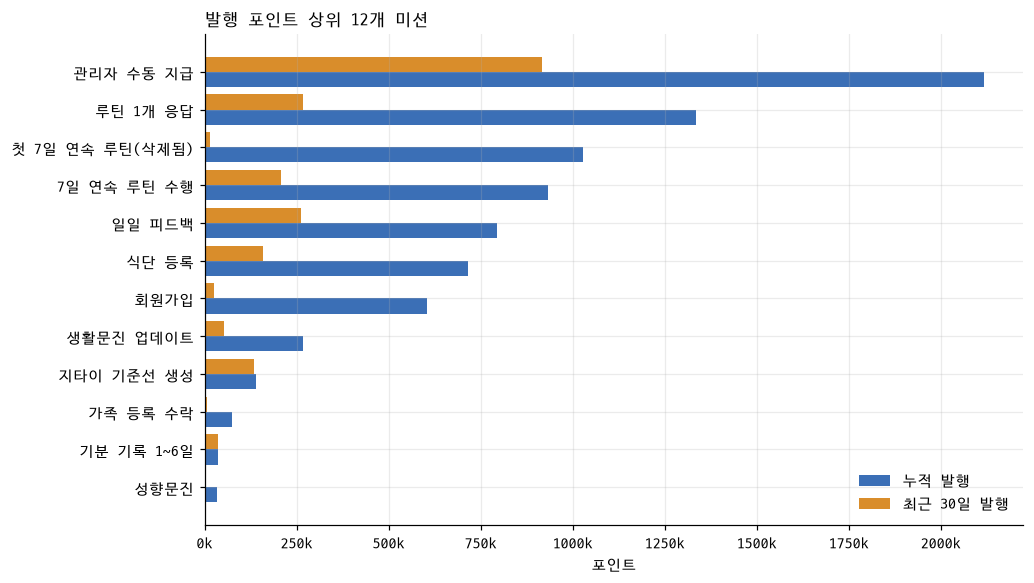

발행 포인트의 80% 를 상위 6개 미션이 차지합니다 (전체 34개 중).


In [78]:
top = liability.sort_values("points_issued", ascending=False).head(12).iloc[::-1]

fig, ax = plt.subplots(figsize=(9.5, 5.4))
y = np.arange(len(top))
ax.barh(y - 0.2, top.points_issued, height=0.4, color=C["issued"], label="누적 발행")
ax.barh(y + 0.2, top.points_issued_30d, height=0.4, color=C["accent"], label="최근 30일 발행")
ax.set_yticks(y, top.label)
ax.set_xlabel("포인트")
ax.xaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda v, _: f"{v/1e3:.0f}k"))
ax.set_title("발행 포인트 상위 12개 미션", loc="left", fontsize=11)
ax.legend(frameon=False, loc="lower right")
plt.show()

share = liability.sort_values("points_issued", ascending=False).copy()
share["누적비중"] = share.points_issued.cumsum() / issued
n80 = int((share.누적비중 < 0.8).sum() + 1)
print(f"발행 포인트의 80% 를 상위 {n80}개 미션이 차지합니다 (전체 {len(share)}개 중).")

In [79]:
view = (liability.sort_values("points_issued", ascending=False)
        .assign(누적비중=lambda d: (d.points_issued.cumsum() / issued))
        .loc[:, ["label", "mission_description", "mission_use_yn",
                 "mission_del_yn", "users_all_time", "points_issued", "누적비중",
                 "points_issued_30d", "points_issued_per_user"]]
        .head(15))
show(view, {"points_issued": "{:,.0f}", "points_issued_30d": "{:,.0f}",
            "points_issued_per_user": "{:,.0f}", "누적비중": "{:.1%}"})

미션,미션 설명,사용,삭제,누적 인원,누적 발행,누적 비중,30일 발행,1인당 발행
관리자 수동 지급,관리자 수동 지급,Y,N,249,"2,117,110",25.7%,"915,000","8,502"
루틴 1개 응답,1개 미션 응답,Y,N,351,"1,335,245",42.0%,"267,915","3,804"
첫 7일 연속 루틴(삭제됨),첫 7일 연속 맞춤루틴 수행,N,Y,209,"1,029,000",54.5%,"15,000","4,923"
7일 연속 루틴 수행,7일 연속 맞춤루틴 수행,Y,N,186,"933,200",65.8%,"207,500","5,017"
일일 피드백,일일 피드백 응답 사용자,Y,N,259,"794,100",75.5%,"261,500","3,066"
식단 등록,당일 식단 관리 등록,Y,N,337,"714,440",84.2%,"158,780","2,120"
회원가입,SNS 회원가입 및 아이디 회원가입으로 회원가입한 사용자,Y,N,1262,"604,100",91.5%,"25,000",479
생활문진 업데이트,생활문진 업데이트,Y,N,499,"267,900",94.8%,"52,300",537
지타이 기준선 생성,기준선 생성(baseline_check_started) / 지타이 적용 시작 + 권한 3종 유지 시,Y,N,56,"140,000",96.5%,"135,000","2,500"
가족 등록 수락,대상자가 등록 후 가족이 수락한 경우,Y,N,66,"75,500",97.4%,"6,000","1,144"


**표 읽는 법.** 미션은 43개지만 **상위 6개가 발행액의 80%를 만듭니다.** 나머지 37개를 아무리
손봐도 금액에는 거의 영향이 없다는 뜻입니다. 비용을 줄이려면 이 표의 위쪽만 보면 됩니다.

눈에 띄는 두 가지가 있습니다.

- **1위가 미션이 아닙니다.** `관리자 수동 지급`은 규칙에 따라 자동으로 나가는 포인트가 아니라
  사람이 직접 지급한 것입니다. 누적 1위이면서 30일 발행에서도 1위입니다.
- **이미 삭제된 미션이 3위입니다.** `첫 7일 연속 루틴`은 `삭제 = Y` 인데도 누적 103만P를
  발행하고 끝났습니다. 미션은 사라졌지만 그때 나간 포인트는 빚으로 그대로 남아 있습니다.

### 1.2 2026-07 급증의 정체

월별 그래프의 7월 급등은 서비스 성장이 아닙니다. 거의 전부 **`관리자 수동 지급`(#101)** 한 항목입니다.
룰 기반 미션의 발행액은 그 에도 전월과 비슷한 수준을 유지했습니다.

In [81]:
admin = liability[liability.point_mission_no == 101].iloc[0]
print(f"관리자 수동 지급 — 누적 {admin.points_issued:,.0f}P "
      f"({admin.points_issued/issued:.1%}), 최근 30일 {admin.points_issued_30d:,.0f}P "
      f"({admin.points_issued_30d/issued_30d:.1%}), 대상 {admin.users_all_time:,.0f}명, "
      f"1인당 {admin.points_issued_per_user:,.0f}P\n")

jul = mth.loc["2026-07-01"] if "2026-07-01" in mth.index.astype(str) else mth.iloc[-2]
peak = mth.sum(axis=1).idxmax()
r_peak, a_peak = mth.loc[peak, False], mth.loc[peak, True]
print(f"발행 최대 월 {peak:%Y-%m} : 총 {r_peak+a_peak:,.0f}P "
      f"= 룰 기반 {r_peak:,.0f}P + 재량 지급 {a_peak:,.0f}P ({a_peak/(r_peak+a_peak):.0%})")
prev = mth.sum(axis=1).shift(1).loc[peak]
print(f"직전월 대비 {(r_peak+a_peak)/prev:.1f}배 — 재량 지급을 빼면 {r_peak/prev:.1f}배\n")

deleted = liability[liability.mission_del_yn == "Y"]
if len(deleted):
    print("삭제된 미션이 남긴 발행액 (부채는 잔액에 그대로 남습니다):")
    for _, r in deleted.iterrows():
        print(f"  #{int(r.point_mission_no)} {r.label}: {r.points_issued:,.0f}P / {r.users_all_time:.0f}명")

off = liability[(liability.mission_use_yn == "N") & (liability.points_issued > 0)]
print(f"\nuse_yn='N' 인데 발행 이력이 있는 미션: {len(off)}개")

관리자 수동 지급 — 누적 2,117,110P (25.7%), 최근 30일 915,000P (43.2%), 대상 249명, 1인당 8,502P

발행 최대 월 2026-07 : 총 3,186,386P = 룰 기반 1,071,386P + 재량 지급 2,115,000P (66%)
직전월 대비 3.0배 — 재량 지급을 빼면 1.0배

삭제된 미션이 남긴 발행액 (부채는 잔액에 그대로 남습니다):
  #35 첫 7일 연속 루틴(삭제됨): 1,029,000P / 209명

use_yn='N' 인데 발행 이력이 있는 미션: 1개


### 1.3 관리자 수동 지급 2,115,000P 는 누구에게 갔는가

In [85]:
recip = audit[audit.is_recipient]
print(f"수령자 {len(recip)}명 / 총 {recip.points_granted.sum():,.0f}P")
print(f"수령자는 전원 임직원 + 울산 참여자 {len(audit)}명 중 {len(recip)}명, {len(recip)/len(audit):.0%}가 수령")
print(f"연령 중앙값 {recip.age.median():.0f}세 · 여성 {(recip.sex=='F').mean():.0%}\n")

batches = (recip.groupby("batch")
           .agg(users=("user_no", "size"), points=("points_granted", "sum"),
                avg_weeks_answered=("weeks_answered_12w", "mean"))
           .rename(index={"batch1_only": "batch1 만 (07-01)",
                          "batch2_only": "batch2 만 (07-29/30)",
                          "both": "두 배치 모두"}))
show(batches, {"points": "{:,.0f}", "avg_weeks_answered": "{:.1f}"}, index=True)

print("1인당 지급액 분포:")
print(recip.points_granted.value_counts().sort_index()
      .rename_axis("지급액(P)").rename("인원").to_string())

수령자 246명 / 총 2,115,000P
수령자는 전원 임직원 + 울산 참여자 442명 중 246명, 56%가 수령
연령 중앙값 67세 · 여성 58%



,인원,포인트,평균 응답 주
batch,,,
batch1 만 (07-01),63,"315,000",5.2
batch2 만 (07-29/30),6,"30,000",11.2
두 배치 모두,177,"1,770,000",11.7


1인당 지급액 분포:
지급액(P)
5000      69
10000    177


**표 읽는 법.** `평균 응답 주`는 지급 직전 12주 동안 루틴에 답한 주가 몇 주였는지입니다.
**두 배치를 모두 받은 177명은 11.7주로 거의 매주 답했지만, batch1만 받은 63명은 5.2주에 그칩니다.**
같은 5,000P를 받았는데 앞선 참여 정도가 두 배 이상 차이 납니다.

지급액은 두 가지뿐입니다 — 한 번만 받은 69명이 5,000P, 두 번 다 받은 177명이 10,000P.
사람마다 금액을 달리 정한 것이 아니라 **정해진 명단에 정액을 뿌린 형태**입니다.

지급은 미션 로직이 아니라 **5,000P 정액 일괄 배치 2건**입니다.

| 배치 | 일자 | 관리자 | 인원 | 금액 |
|---|---|---|---|---|
| batch1 | 2026-07-01 | admin #5 | 240명 | 1,200,000P |
| batch2 | 2026-07-29 | admin #2 | 182명 | 910,000P |
| — | 2026-07-30 | admin #2 | 1명 | 5,000P |

#### 지급 기준은 무엇이었나

카탈로그에 **정확히 5,000P 짜리 미션이 두 개** 있는데, 둘 다 적립 이력이 0건입니다.

- `#41 (울산) 12주 동안 주 1회 이상 미션을 응답한 사용자` — 5,000P
- `#42 (울산) 만족도 조사 완료한 사용자` — 5,000P

`#41` 의 조건을 그대로 재현해 수령자와 미수령자를 비교하면 분리가 뚜렷합니다.

,인원,평균 응답 주,응답 0주,12주 전부 응답
is_recipient,,,,
미수령 사용자,196,1.5,140,3
수령자,246,10.0,9,114


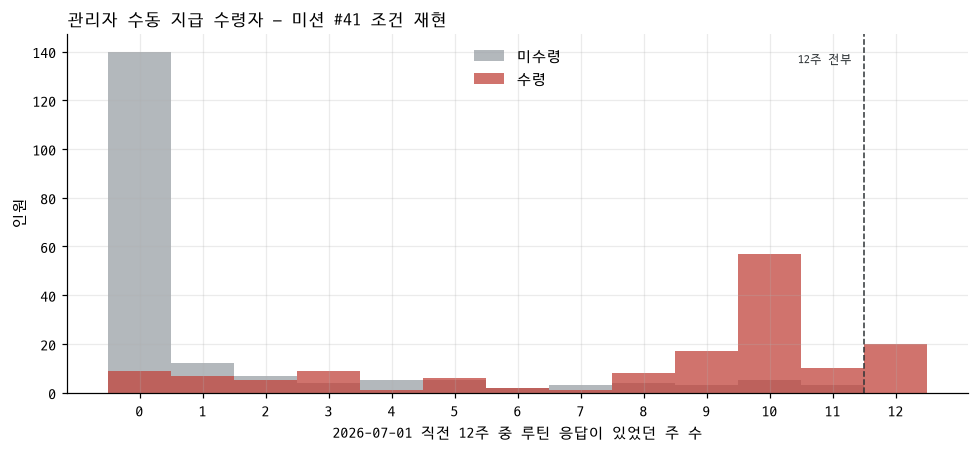

In [9]:
grp = audit.groupby("is_recipient").agg(
    users=("user_no", "size"),
    avg_weeks=("weeks_answered_12w", "mean"),
    n_zero_weeks=("weeks_answered_12w", lambda s: int((s == 0).sum())),
    n_meets_rule=("meets_12w_rule", "sum"))
grp.index = grp.index.map({True: "수령자", False: "미수령 사용자"})
show(grp, {"avg_weeks": "{:.1f}"}, index=True)

fig, ax = plt.subplots(figsize=(9, 4.2))
bins = np.arange(0, 14) - 0.5
for flag, name, col in [(False, "미수령", C["muted"]), (True, "수령", C["outstanding"])]:
    ax.hist(audit.loc[audit.is_recipient == flag, "weeks_answered_12w"],
            bins=bins, alpha=0.75, label=name, color=col)
ax.set_xticks(range(13))
ax.set_xlabel("2026-07-01 직전 12주 중 루틴 응답이 있었던 주 수")
ax.set_ylabel("인원")
ax.set_title("관리자 수동 지급 수령자 — 미션 #41 조건 재현",
             loc="left", fontsize=11)
ax.axvline(11.5, color=C["dark"], ls="--", lw=1)
ax.text(11.4, ax.get_ylim()[1] * 0.92, "12주 전부 ", ha="right", fontsize=8, color=C["dark"])
ax.legend(frameon=False)
plt.show()

**표와 그래프 읽는 법.** 두 집단의 차이가 우연으로 보기 어려울 만큼 큽니다.
수령자 246명은 12주 중 평균 **10.0주** 답했지만, 받지 못한 196명은 평균 **1.5주**입니다.
받지 못한 쪽은 **140명(71%)이 아예 한 주도 답하지 않았습니다.**

그래프에서도 두 무리가 좌우로 갈라집니다. 회색(미수령)은 0주에 몰려 있고, 붉은색(수령)은
9~12주 구간에 몰려 있습니다. 즉 **지급 대상은 무작위가 아니라 꾸준히 응답한 사람들**이었습니다.

다만 수령자 중에도 0주가 9명, 12주를 전부 채운 사람은 114명뿐이라 규칙이 딱 떨어지지는 않습니다.

배치 인원(240명 / 182명), 정액 5,000P, 그리고 해당 미션들이 한 번도 발화하지 않았다는 사실을 합치면
**자동 지급됐어야 할 미션 보상을 수기로 대납한 것**으로 보입니다.

다만, 지금 이 데이터에서는 실제 울산 실증사업 참여자와 임직원을 분리해서 보지는 못하므로, 어떤 기준으로 누구에게 지급되었는지는 별도 확인이 필요합니다.

---
## 2. 발행 집중도 — 무분별하게 새는 포인트 찾기

"무분별"하게 지급된 포인트는 다음 두 가지 기준으로 파악하였습니다.

1. **사용자 편중** — 소수 사용자가 발행액의 큰 몫을 가져가는가 (Gini, 상위 10% 점유율)
2. **재량 지급** — 룰 없이 나가는 포인트의 비중

Gini 는 0(완전 균등) ~ 1(한 사람 독식). 미션 성격상 어느 정도 편차는 정상이므로,
같은 성격(카테고리)의 미션끼리 비교하는 용도로 사용했습니다.

In [10]:
def gini(x: np.ndarray) -> float:
    """포인트 분배의 지니계수. 값이 없거나 전부 0이면 NaN."""
    x = np.sort(np.asarray(x, dtype=float))
    if x.size == 0 or x.sum() == 0:
        return np.nan
    n = x.size
    return float((2 * np.arange(1, n + 1) - n - 1).dot(x) / (n * x.sum()))


def top_share(x: np.ndarray, q: float = 0.10) -> float:
    """상위 q 비율 사용자가 가져간 포인트 몫."""
    x = np.sort(np.asarray(x, dtype=float))[::-1]
    if x.size == 0 or x.sum() == 0:
        return np.nan
    k = max(1, int(np.ceil(x.size * q)))
    return float(x[:k].sum() / x.sum())


conc = (earn.groupby("point_mission_no")
        .agg(earners=("user_no", "nunique"),
             points=("points_30d", "sum"),
             gini=("points_30d", lambda s: gini(s.values)),
             top10_share=("points_30d", lambda s: top_share(s.values)),
             max_user_points=("points_30d", "max"))
        .reset_index())
conc["label"] = conc.point_mission_no.map(label)
conc["points_per_earner"] = conc.points / conc.earners
conc["max_user_share"] = conc.max_user_points / conc.points

focus = conc[conc.earners >= 20].sort_values("gini", ascending=False)
show(focus[["label", "earners", "points", "points_per_earner",
            "gini", "top10_share", "max_user_share"]],
     {"points": "{:,.0f}", "points_per_earner": "{:,.0f}",
      "gini": "{:.3f}", "top10_share": "{:.1%}", "max_user_share": "{:.1%}"})

미션,적립자,포인트,적립자당 포인트,지니계수,상위10% 몫,최다 1인 몫
댓글 쓰기,28,"2,280",81,0.727,59.4%,25.4%
글쓰기(30자+),32,"1,610",50,0.624,62.1%,23.0%
좋아요 10개,27,597,22,0.569,37.2%,14.1%
일일 피드백,201,"198,900",990,0.523,29.8%,1.5%
출석 1·2·4·5일차,270,"1,590",6,0.503,29.6%,1.2%
식단 등록,155,"127,300",821,0.454,22.2%,1.4%
루틴 1개 응답,246,"207,900",845,0.416,21.2%,0.9%
출석 3·6일차,101,868,9,0.396,22.4%,2.1%
기분 기록 1~6일,214,"33,750",158,0.340,19.6%,0.9%
생활문진 업데이트,208,"42,200",203,0.281,20.1%,1.2%


**표 읽는 법.** 지니계수는 그 미션의 포인트가 얼마나 소수에게 몰렸는지를 나타냅니다
(0이면 적립자 모두가 똑같이 받음, 1에 가까울수록 한두 명이 독식).

**다만 이 표만 보고 "새고 있다"고 판단하면 안 됩니다.** 지니가 높은 상위권은 `댓글 쓰기`(0.727),
`글쓰기`(0.624), `좋아요 10개`(0.569)처럼 **적립자가 30명 안팎인 작은 미션**들입니다. 사람이 적으면
한 명만 열심히 해도 지니가 쉽게 올라가고, 실제 금액은 다 합쳐야 수천 P 수준이라 부채에 주는 영향이
거의 없습니다.

반대로 `주간 체크업`처럼 지니가 0에 가까운 미션은 조건을 채운 사람 모두가 똑같은 금액을 받는
구조라는 뜻입니다. 문제가 있다는 신호가 아닙니다.

**실제로 봐야 할 것은 "금액이 크면서 동시에 편중된" 칸입니다.** `일일 피드백`(19.9만P, 지니 0.523)이
그 조건에 가장 가깝습니다.

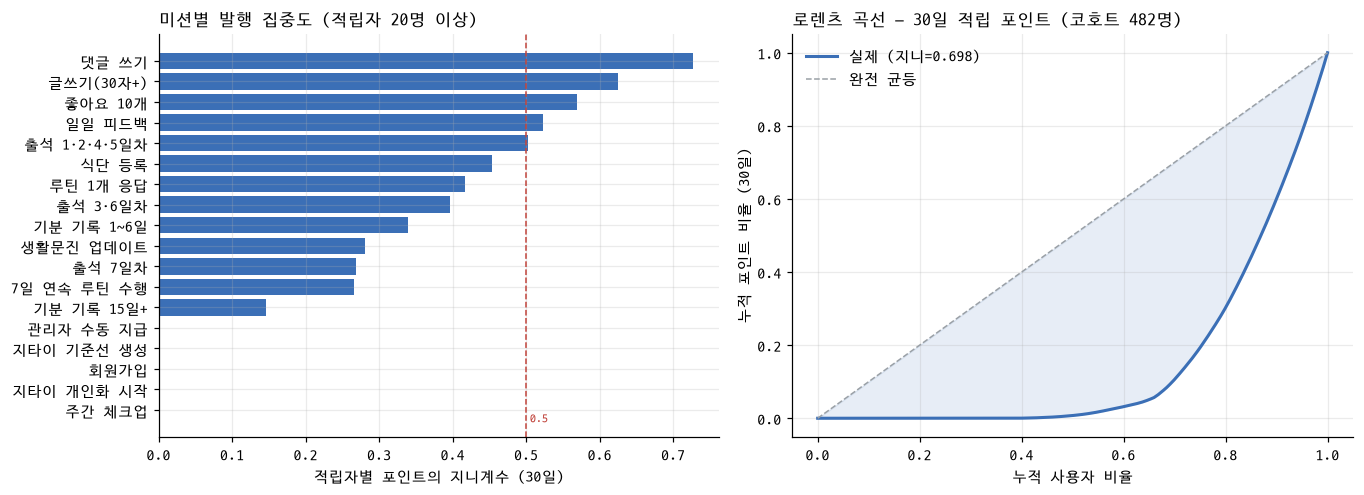

30일 적립 포인트 1,696,428P · 코호트 482명 · 지니 0.698

  상위 10% (49명) 이 가져간 몫 : 40.5%
  상위 20% (97명) 이 가져간 몫 : 70.1%
  하위 50% (241명) 이 가져간 몫 : 0.7%

  0P 인 사람 157명(33%) 을 빼고
  실제 적립자 325명만 보면 지니는 0.553 로 내려갑니다.

  상위 10% : 방문 29.8일 · 루틴 수행 115건
  나머지   : 방문 11.8일 · 루틴 수행 29건
  적립 포인트와 방문일수의 순위상관 : 0.893


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6))

# (a) 미션별 집중도
ax = axes[0]
f = focus.sort_values("gini")
ax.barh(f.label, f.gini, color=C["issued"])
ax.set_xlabel("적립자별 포인트의 지니계수 (30일)")
ax.set_title("미션별 발행 집중도 (적립자 20명 이상)", loc="left", fontsize=11)
ax.axvline(0.5, color=C["outstanding"], ls="--", lw=1)
ax.text(0.505, -0.6, "0.5", color=C["outstanding"], fontsize=8)

# (b) 사용자 단위 로렌츠 곡선
ax = axes[1]
pts = np.sort(users.points_earned_30d.values)
cum = np.concatenate([[0], np.cumsum(pts) / pts.sum()])
frac = np.linspace(0, 1, cum.size)
ax.plot(frac, cum, color=C["issued"], lw=2, label=f"실제 (지니={gini(pts):.3f})")
ax.plot([0, 1], [0, 1], color=C["muted"], ls="--", lw=1, label="완전 균등")
ax.fill_between(frac, cum, frac, color=C["issued"], alpha=0.12)
ax.set_xlabel("누적 사용자 비율")
ax.set_ylabel("누적 포인트 비율 (30일)")
ax.set_title("로렌츠 곡선 — 30일 적립 포인트 (코호트 482명)", loc="left", fontsize=11)
ax.legend(frameon=False, loc="upper left")
plt.show()

pts_all = users.points_earned_30d.values
s = np.sort(pts_all)[::-1]
k10, k20 = int(np.ceil(len(s) * 0.1)), int(np.ceil(len(s) * 0.2))
top10 = s[:k10].sum() / s.sum()
n_zero = int((pts_all == 0).sum())

print(f"30일 적립 포인트 {pts_all.sum():,.0f}P · 코호트 {len(pts_all)}명 · 지니 {gini(pts_all):.3f}\n")
print(f"  상위 10% ({k10}명) 이 가져간 몫 : {top10:.1%}")
print(f"  상위 20% ({k20}명) 이 가져간 몫 : {s[:k20].sum()/s.sum():.1%}")
print(f"  하위 50% ({len(s)//2}명) 이 가져간 몫 : {s[len(s)//2:].sum()/s.sum():.1%}")
print(f"\n  0P 인 사람 {n_zero}명({n_zero/len(pts_all):.0%}) 을 빼고")
print(f"  실제 적립자 {len(pts_all)-n_zero}명만 보면 지니는 {gini(pts_all[pts_all>0]):.3f} 로 내려갑니다.")

top = users.nlargest(k10, "points_earned_30d")
rest = users.drop(top.index)
print(f"\n  상위 10% : 방문 {top.visit_days_30d.mean():.1f}일 · 루틴 수행 {top.routine_done_30d.mean():.0f}건")
print(f"  나머지   : 방문 {rest.visit_days_30d.mean():.1f}일 · 루틴 수행 {rest.routine_done_30d.mean():.0f}건")
print(f"  적립 포인트와 방문일수의 순위상관 : "
      f"{users.points_earned_30d.corr(users.visit_days_30d, method='spearman'):.3f}")

**로렌츠 곡선 읽는 법.** 대각선은 "모두가 똑같이 받았다"는 가상의 선입니다. 실제 곡선이
아래로 처질수록 소수에게 몰려 있다는 뜻이고, 그 처진 정도를 하나의 숫자로 요약한 것이
지니계수입니다(0 = 완전 균등, 1 = 한 사람 독식).

지니 0.698 은 상당히 몰려 있는 수준입니다. 다만 이 숫자를 곧바로 "포인트가 새고 있다"는
뜻은 아닙니다. 그 아유는 다음과 같습니다.

**첫째, 편중의 상당 부분은 아예 못 받은 사람 때문입니다.** 코호트 482명 중 157명(33%)이
30일간 0P 입니다. 실제로 포인트를 받은 325명만 놓고 다시 계산하면 지니는 0.553 으로
내려갑니다. "참여자들 사이의 격차"보다 "참여했느냐 안 했느냐"의 격차가 더 큽니다.

**둘째, 많이 받은 사람이 실제로 앱을 많이 쓴 사람입니다.** 상위 10%는 30일 중 29.8일을
방문했고(나머지 11.8일) 루틴을 116건 수행했습니다(나머지 30건). 적립 포인트와 방문일수의
순위상관은 0.893 으로 사실상 같이 움직입니다. 이 편중은 **설계한 대로 작동한 결과**입니다.

그래서 여기서 찾아야 할 것은 "포인트 지급의 편중이 크다"가 아니라 **"활동 없이 편중된 곳이 있는가"** 입니다.
왼쪽 차트에서 유독 한쪽으로 쏠린 미션을 골라, 그 상위 수령자의 활동이 평범한지 확인하는 것이
다음 단계입니다.

한편 부채 관리 관점에서는 **상위 20%가 70%를 가져간다**는 사실이 미션 개수보다 중요합니다.
소액 미션 여러 개를 정리하는 것보다 상위 사용자 대상 정책(1인당 상한, 소멸 기한)을 손보는 쪽이
금액에 훨씬 크게 작용될 수 있을 것 같습니다.

---
## 3. 사용자 활동의 상관 구조

미션별 분석에 들어가기 전에, 활동 지표들이 서로 얼마나 겹치는지부터 확인하였습니다.
활동 지표가 서로 강하게 상관돼 있다면 "이 미션 참여자가 활동적이다"는 관찰은
거의 모든 미션에서 자동으로 성립하게 되고, 그만큼 미션별 차이를 파악하기 어려워집니다.

분포가 크게 치우쳐 있어 **Spearman 순위상관**을 사용했습니다. <br>  (두 변수의 실제 값 대신 순위(rank)를 이용해 상관관계를 파악하는 비모수적 통계 방법)

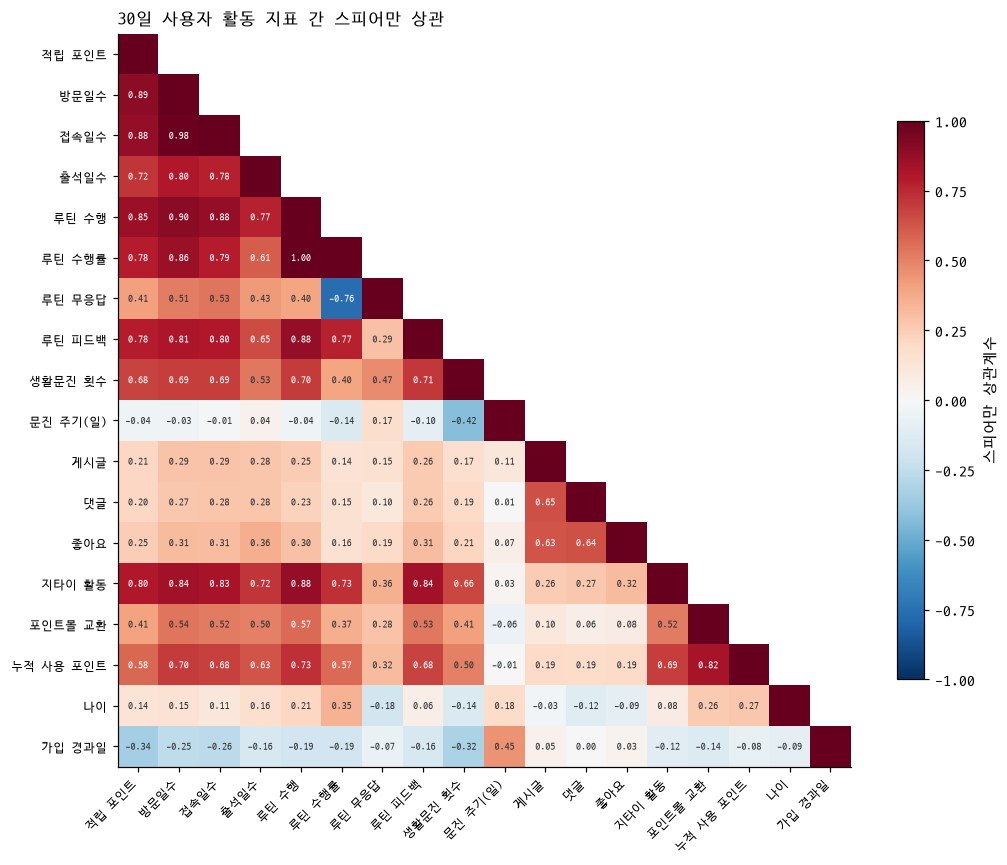

In [12]:
METRICS = {
    "points_earned_30d":       "적립 포인트",
    "visit_days_30d":          "방문일수",
    "login_days_30d":          "접속일수",
    "attendance_days_30d":     "출석일수",
    "routine_done_30d":        "루틴 수행",
    "routine_done_rate_30d":   "루틴 수행률",
    "routine_no_response_30d": "루틴 무응답",
    "routine_fdbk_cnt_30d":    "루틴 피드백",
    "survey_cnt_30d":          "생활문진 횟수",
    "survey_median_gap_days":  "문진 주기(일)",
    "post_publish_cnt_30d":    "게시글",
    "comment_cnt_30d":         "댓글",
    "post_like_cnt_30d":       "좋아요",
    "jitai_action_cnt_30d":    "지타이 활동",
    "coupon_issue_cnt_30d":    "포인트몰 교환",
    "points_spent_total":      "누적 사용 포인트",
    "age":                     "나이",
    "tenure_days":             "가입 경과일",
}

corr = users[list(METRICS)].corr(method="spearman")
corr.index = corr.columns = list(METRICS.values())

fig, ax = plt.subplots(figsize=(9.6, 8.2))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
im = ax.imshow(np.where(mask, np.nan, corr), cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr)), corr.columns, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(corr)), corr.index, fontsize=8)
for i in range(len(corr)):
    for j in range(i + 1):
        v = corr.iloc[i, j]
        if i != j:
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=6.5,
                    color="white" if abs(v) > 0.55 else C["dark"])
ax.set_title("30일 사용자 활동 지표 간 스피어만 상관", loc="left", fontsize=11)
ax.grid(False)
fig.colorbar(im, ax=ax, shrink=0.7, label="스피어만 상관계수")
plt.show()

`루틴 수행` 과 `루틴 수행률` 은 ρ = 0.997 로 사실상 같은 변수입니다(배정 루틴 수가 사용자별로
크게 다르지 않아서입니다). 성과 지표로는 루틴 수행률로만 보겠습니다.

In [86]:
pe = corr.loc["적립 포인트"].drop("적립 포인트").sort_values(ascending=False)
print("포인트 적립량과 가장 강하게 함께 움직이는 지표 (Spearman):")
for name, v in pe.head(6).items():
    print(f"  {v:+.3f}  {name}")
print("\n가장 약하거나 반대 방향:")
for name, v in pe.tail(3).items():
    print(f"  {v:+.3f}  {name}")

포인트 적립량과 가장 강하게 함께 움직이는 지표 (Spearman):
  +0.893  방문일수
  +0.875  접속일수
  +0.853  루틴 수행
  +0.800  지타이 활동
  +0.783  루틴 수행률
  +0.782  루틴 피드백

가장 약하거나 반대 방향:
  +0.140  나이
  -0.041  문진 주기(일)
  -0.343  가입 경과일


---
## 4. 미션별 참여 효과 — 전체 활동량을 통제한 뒤

각 미션에 대해 "이 미션을 적립한 사람"과 "적립하지 않은 사람"의 **루틴 수행률**을 비교합니다.
루틴 수행률을 핵심 성과 지표로 잡은 이유는, 이 앱이 실제로 팔고 있는 가치가
커뮤니티 활동이 아니라 **건강 루틴의 지속**이기 때문입니다.

그냥 비교하면 "활발한 사람은 뭐든 다 한다"는 교란이 그대로 들어옵니다. 그래서
`visit_days_30d`(전체 접속량)을 통제 변수로 넣은 OLS 회귀의 참여 더미 계수를 함께 파악하였습니다.

- `raw_diff` — 단순 평균 차이 (교란 포함)
- `adj_coef` — 접속일수를 통제한 뒤의 차이 ← **이쪽을 본다**
- `p_adj` — 그 계수의 p-value. 0.05 보다 작으면 우연으로 보기 어려운 차이라는 뜻입니다.

> **한 가지 예외.** `루틴 1개 응답`, `7일 연속 루틴 수행`, `일일 피드백` 세 미션은
> 포인트를 주는 조건 자체가 루틴에 응답하는 것입니다. 성과 지표인 루틴 수행률과 같은 행동이라
> 수치가 높게 나오는 것이 당연하므로, 이 세 개는 다른 미션들과 동일한 기준으로 판단할 수는 없습니다.

In [88]:
import statsmodels.api as sm

# 루틴이 배정된 사용자만 대상 (루틴 수행률이 정의되는 모집단)
pop = users[users.routine_assigned_30d > 0].copy()
OUTCOME, CONTROL = "routine_done_rate_30d", "visit_days_30d"
pop = pop.dropna(subset=[OUTCOME, CONTROL])
print(f"분석 모집단: {len(pop)}명 (30일 내 루틴이 배정된 사용자)")

earners_by_mission = earn.groupby("point_mission_no").user_no.apply(set)

rows = []
for no, uset in earners_by_mission.items():
    d = pop.assign(joined=pop.user_no.isin(uset).astype(int))
    n1, n0 = int(d.joined.sum()), int((1 - d.joined).sum())
    if n1 < 20 or n0 < 20:          # 양쪽 집단이 너무 작으면 추정이 불안정
        continue
    a, b = d.loc[d.joined == 1, OUTCOME], d.loc[d.joined == 0, OUTCOME]
    model = sm.OLS(d[OUTCOME], sm.add_constant(d[["joined", CONTROL]])).fit()
    rows.append({
        "point_mission_no": no, "label": label(no),
        "n_joined": n1, "n_not": n0,
        "mean_joined": a.mean(), "mean_not": b.mean(),
        "raw_diff": a.mean() - b.mean(),
        "p_raw": stats.mannwhitneyu(a, b, alternative="two-sided").pvalue,
        "adj_coef": model.params["joined"],
        "p_adj": model.pvalues["joined"],
    })

eff = pd.DataFrame(rows).sort_values("adj_coef", ascending=False)
show(eff, {"mean_joined": "{:.3f}", "mean_not": "{:.3f}", "raw_diff": "{:+.3f}",
          "p_raw": "{:.2g}", "adj_coef": "{:+.3f}", "p_adj": "{:.2g}"})

분석 모집단: 303명 (30일 내 루틴이 배정된 사용자)


미션번호,미션,적립자,미적립자,적립자 평균,미적립자 평균,단순 차이,p(단순),조정 계수,p(조정)
36,7일 연속 루틴 수행,122,181,0.749,0.242,+0.507,6.4e-36,+0.231,2.4e-16
39,일일 피드백,201,102,0.606,0.132,+0.474,6.2e-32,+0.180,2e-10
109,주간 체크업,150,153,0.662,0.235,+0.428,2.3e-27,+0.164,2.1e-10
16,출석 7일차,56,247,0.762,0.375,+0.387,1.8e-14,+0.139,3.5e-06
101,관리자 수동 지급,147,156,0.658,0.247,+0.411,3.6e-25,+0.131,6.7e-07
15,출석 3·6일차,99,204,0.680,0.333,+0.347,9.9e-17,+0.109,2.2e-05
37,루틴 1개 응답,246,57,0.539,0.048,+0.491,9.3e-27,+0.091,0.0097
38,식단 등록,155,148,0.614,0.270,+0.344,9e-19,+0.084,0.00095
104,기분 기록 1~6일,214,89,0.572,0.144,+0.428,1.3e-24,+0.070,0.024
103,지타이 기준선 생성,49,254,0.700,0.397,+0.303,2.1e-08,+0.059,0.063


**표 읽는 법.** `단순 차이`와 `조정 계수` 두 열을 나란히 보는 것.

- `단순 차이` — 미션을 받은 사람과 안 받은 사람의 루틴 수행률을 **그냥** 비교한 값
- `조정 계수` — 앱에 들어온 날수가 **비슷한 사람들끼리** 비교했을 때 남는 차이

예를 들어 `7일 연속 루틴 수행`은 단순 비교로는 +0.507(50.7%p) 차이가 나지만, 조정 후에는
+0.231(23.1%p)로 절반 아래로 줄어듭니다. **줄어든 만큼은 미션의 힘이 아니라 "원래 앱을 자주 쓰는
사람이라서" 생긴 차이**였습니다. 표의 거의 모든 미션에서 이런 축소가 일어납니다.

`p(조정)` 은 그 차이가 우연일 가능성입니다. **0.05보다 작으면 우연으로 보기 어렵다**는 뜻이고,
0.05보다 크면 차이가 있다고 말하기 어렵습니다.

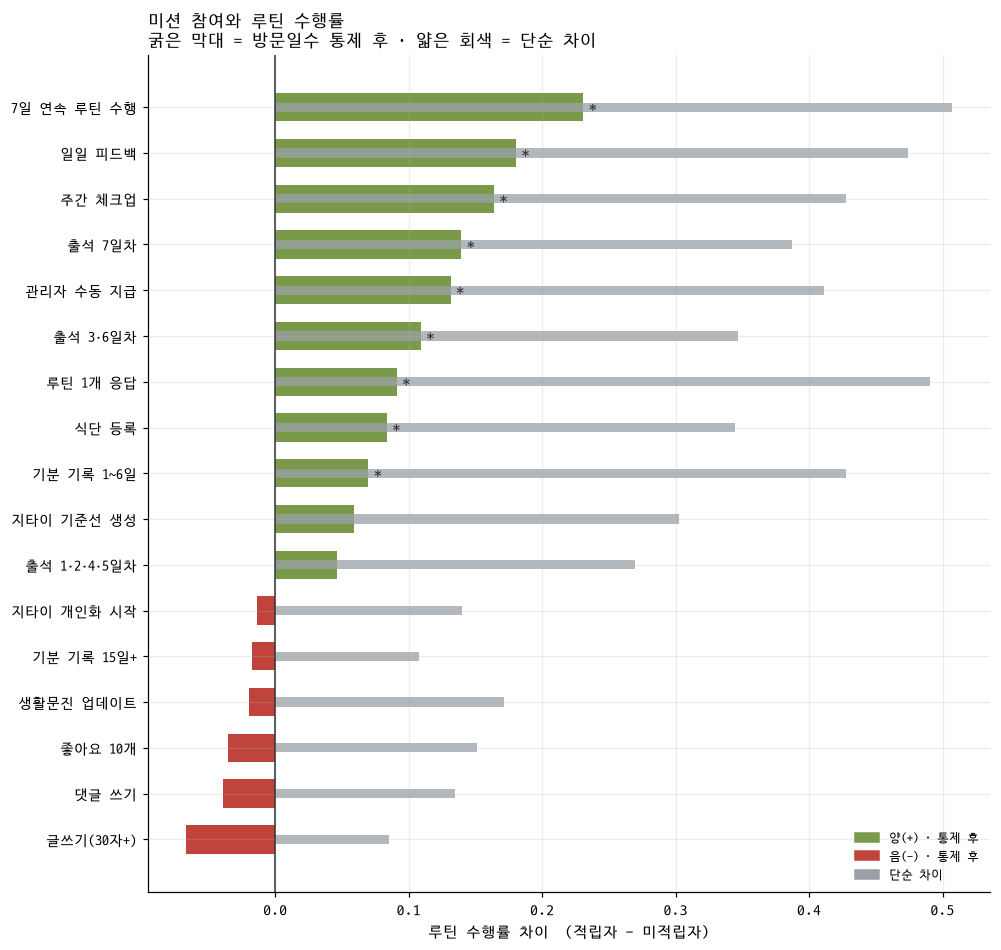

*  조정 계수의 p < 0.05


In [15]:
fig, ax = plt.subplots(figsize=(9.2, 0.42 * len(eff) + 1.6))
e = eff.sort_values("adj_coef")
y = np.arange(len(e))
cols = [C["used"] if c > 0 else C["outstanding"] for c in e.adj_coef]
ax.barh(y, e.adj_coef, color=cols, height=0.62)
ax.barh(y, e.raw_diff, color=C["muted"], height=0.2, alpha=0.75)
ax.set_yticks(y, e.label, fontsize=9)
ax.axvline(0, color=C["dark"], lw=1)
ax.set_xlabel("루틴 수행률 차이  (적립자 − 미적립자)")
ax.set_title("미션 참여와 루틴 수행률\n"
             "굵은 막대 = 방문일수 통제 후 · 얇은 회색 = 단순 차이",
             loc="left", fontsize=11)
for yi, (c, p) in enumerate(zip(e.adj_coef, e.p_adj)):
    if p < 0.05:
        ax.text(c + (0.004 if c >= 0 else -0.004), yi, "*",
                va="center", ha="left" if c >= 0 else "right", fontsize=11, color=C["dark"])
handles = [mpl.patches.Patch(color=C["used"], label="양(+) · 통제 후"),
           mpl.patches.Patch(color=C["outstanding"], label="음(−) · 통제 후"),
           mpl.patches.Patch(color=C["muted"], label="단순 차이")]
ax.legend(handles=handles, frameon=False, loc="lower right", fontsize=8)
plt.show()
print("*  조정 계수의 p < 0.05")

**그래프 읽는 법.** 미션마다 막대가 두 개씩 붙어 있습니다.

- **얇은 회색 막대** — 미션을 받은 사람과 받지 않은 사람의 루틴 수행률을 **그냥** 비교한 차이
- **굵은 막대** — 앱에 들어온 날수가 **비슷한 사람들끼리** 비교했을 때 남는 차이

거의 모든 미션에서 **굵은 막대가 회색 막대보다 훨씬 짧습니다.** 맨 위 `7일 연속 루틴 수행`을 보면,
그냥 비교했을 때는 수행률이 50.7%p 차이가 나지만 비슷한 사람끼리 비교하면 23.1%p로 줄어듭니다.

줄어든 27.6%p는 **미션이 만들어낸 차이가 아닙니다.** 이 미션을 받은 사람들이 원래부터 앱을 자주
쓰던 사람들이라서 생긴 차이입니다. 그냥 비교하면 이 부분까지 미션의 공으로 잘못 계산됩니다.

**그래서 회색 막대는 참고만 하시고, 굵은 막대를 보시면 됩니다.** 굵은 막대가 오른쪽(초록)에 남아
있고 옆에 `*` 표시가 붙은 미션이, 부지런함의 차이를 걷어내고도 루틴 수행률과의 연결이 확인된
미션입니다.

굵은 막대가 왼쪽(빨강)으로 간 미션은 오히려 수행률이 낮았다는 뜻이지만, 여기에는 `*` 가 하나도
붙어 있지 않습니다. 우연일 수 있는 수준이라 "효과가 없다"고 단정하지는 않습니다.

---
## 5. 대체 가능성 — 이 미션을 없애면 실제로 잃는 사용자는 몇 명인가

미션을 없앨 수 있는지 판단하는 가장 직접적인 질문입니다.
어떤 미션의 적립자가 전부 다른 미션에서도 적립하고 있다면, 그 미션을 없애도
**포인트 지출만 줄고 도달하는 사용자 수는 그대로**다.

- `exclusive_earners` — 30일간 **이 미션에서만** 적립한 사용자 수
- `points_30d` — 그 미션이 30일간 발행한 포인트 (= 없앴을 때 절약되는 부채)

> `exclusive_earners = 0` 은 "없애도 된다"는 뜻이 **아니다**. 없애도 포인트를 받는 사용자 수는
> 줄지 않는다는 뜻일 뿐, 그 미션이 유도하던 행동의 유인은 함께 사라집니다.
> 폐지 판단이 아니라 **지급액을 낮출 여지**를 찾는 지표로 씁니다.

In [89]:
missions_per_user = earn.groupby("user_no").point_mission_no.nunique()
solo_users = set(missions_per_user[missions_per_user == 1].index)

overlap = (earn.groupby("point_mission_no")
           .agg(earners=("user_no", "nunique"),
                exclusive_earners=("user_no", lambda s: len(set(s) & solo_users)))
           .reset_index())
overlap["label"] = overlap.point_mission_no.map(label)
overlap = overlap.merge(
    liability[["point_mission_no", "points_issued_30d", "mission_use_yn"]],
    on="point_mission_no", how="left")
overlap["exclusive_rate"] = overlap.exclusive_earners / overlap.earners
overlap["points_per_exclusive"] = np.where(
    overlap.exclusive_earners > 0,
    overlap.points_issued_30d / overlap.exclusive_earners, np.nan)

show(overlap.sort_values("points_issued_30d", ascending=False)
     [["label", "earners", "exclusive_earners", "exclusive_rate",
       "points_issued_30d", "points_per_exclusive"]],
     {"exclusive_rate": "{:.1%}", "points_issued_30d": "{:,.0f}",
      "points_per_exclusive": "{:,.0f}"})

print(f"30일 적립자 {earn.user_no.nunique()}명 중 단 한 개 미션에서만 적립한 사용자: {len(solo_users)}명")

미션,적립자,전속 적립자,전속 비율,30일 발행,전속 1인당 포인트
관리자 수동 지급,148,1,0.7%,"915,000","915,000"
루틴 1개 응답,246,2,0.8%,"267,915","133,958"
일일 피드백,201,0,0.0%,"261,500",nan
7일 연속 루틴 수행,122,0,0.0%,"207,500",nan
식단 등록,155,0,0.0%,"158,780",nan
지타이 기준선 생성,49,0,0.0%,"135,000",nan
생활문진 업데이트,208,7,3.4%,"52,300","7,471"
기분 기록 1~6일,214,1,0.5%,"35,450","35,450"
회원가입,25,11,44.0%,"25,000","2,273"
주간 체크업,150,0,0.0%,"16,000",nan


30일 적립자 325명 중 단 한 개 미션에서만 적립한 사용자: 46명


**표 읽는 법.** `전속 적립자`는 30일 동안 **오직 그 미션에서만** 포인트를 받은 사람 수입니다.
0명이면, 그 미션을 없애도 포인트를 받는 사람 수는 한 명도 줄지 않습니다 — 그 사람들은 어차피
다른 미션에서도 받고 있기 때문입니다.

28개 미션 중 **20개가 전속 적립자 0명**입니다. 여기에 30일 발행 82만P가 묶여 있습니다.

**다만 이것을 "없애도 된다"로 읽으면 안 됩니다.** 사람 수는 안 줄어도, 그 미션이 유도하던 행동
(식단을 기록하게 하고, 피드백에 답하게 하는)의 유인은 함께 사라집니다. 이 표는 **폐지 후보를 고르는
용도가 아니라, 지급액을 낮춰도 될 후보를 고르는 용도**입니다.

예외적으로 `출석 1·2·4·5일차`는 전속 적립자가 21명으로 가장 많습니다. 이 미션만으로 포인트를
접하는 사용자가 있다는 뜻이라, 손대면 도달 범위가 실제로 줄어듭니다.

### 5.1 30일간 한 번도 적립되지 않은 미션

In [90]:
active_30d = set(earn.point_mission_no.unique())
dead = catalog[(~catalog.point_mission_no.isin(active_30d))].copy()
dead["상태"] = np.where(dead.use_yn == "Y", "사용중(use_yn=Y)", "중단(use_yn=N)")
show(dead[["point_mission_no", "label", "description", "상태", "amount",
           "total_unique_users", "last_earn_at"]]
     .sort_values(["상태", "total_unique_users"], ascending=[True, False]))

live_dead = dead[dead.use_yn == "Y"]
print(f"use_yn='Y' 인데 30일간 적립 0건인 미션: {len(live_dead)}개 / 전체 {len(catalog)}개")

미션번호,미션,설명,상태,지급액,누적 적립자,마지막 적립
2,성향문진,성향문진을 통한 사용자 유형 카드 1장 보유,사용중(use_yn=Y),100,309,2025-12-29 07:36:53.095563+09
105,기분 기록 7일,기분 기록 7일,사용중(use_yn=Y),500,31,2026-08-05 10:05:16.024963+09
24,친구 초대 21~50명,"친구 초대 (21~50, 5명당)",사용중(use_yn=Y),100,2,2025-08-26 16:31:33.797194+09
41,12주 완주,12주 동안 주 1회 이상 미션을 응답한 사용자,사용중(use_yn=Y),5000,0,nan
42,만족도 조사,만족도 조사 완료한 사용자,사용중(use_yn=Y),5000,0,nan
106,기분 기록 8~13일,기분 기록 8~13일,사용중(use_yn=Y),100,0,nan
107,기분 기록 14일,기분 기록 14일,사용중(use_yn=Y),1000,0,nan
22,친구 초대 10·20명,"친구 초대 (10, 20명)",사용중(use_yn=Y),1200,0,nan
23,친구 초대 15명,친구 초대 (15명),사용중(use_yn=Y),200,0,nan
25,친구 초대 51~100명,"친구 초대 (51~100, 10명당)",사용중(use_yn=Y),100,0,nan


use_yn='Y' 인데 30일간 적립 0건인 미션: 10개 / 전체 43개


**표 읽는 법.** `사용중(use_yn=Y)`인데 30일간 적립이 0건인 미션이 **10개**입니다. 어드민 화면에는
살아 있지만 실제로는 아무도 달성하지 않는, 사실상 방치된 미션들입니다.

이 중 **7개는 누적 적립자도 0명**입니다. 한 번도 지급된 적이 없다는 뜻입니다. 특히 `12주 완주`와
`만족도 조사`는 각각 5,000P짜리인데 적립 이력이 0건입니다 — 1.3 절에서 다룬 관리자 수동 지급
2,115,000P가 바로 이 두 미션이 했어야 할 지급으로 보이는 이유입니다.

당장 금액이 나가고 있지는 않지만, **조건이 갑자기 충족되면 예고 없이 부채가 늘어날 수 있는
미션들**이므로 정리 대상으로 확인이 필요합니다.

---
## 6. 비용 × 효과 매트릭스

가로축은 30일 발행 포인트(= 부채 증가분), 세로축은 4절의 조정 계수(= 루틴 지속과의 연관).
버블 크기는 도달 사용자 수입니다.

- **오른쪽 아래** — 돈은 많이 나가는데 성과와 연결되지 않음 → 축소·폐지 검토
- **오른쪽 위** — 돈은 나가지만 성과와 연결됨 → 유지
- **왼쪽** — 지출 자체가 작아 우선순위가 낮음

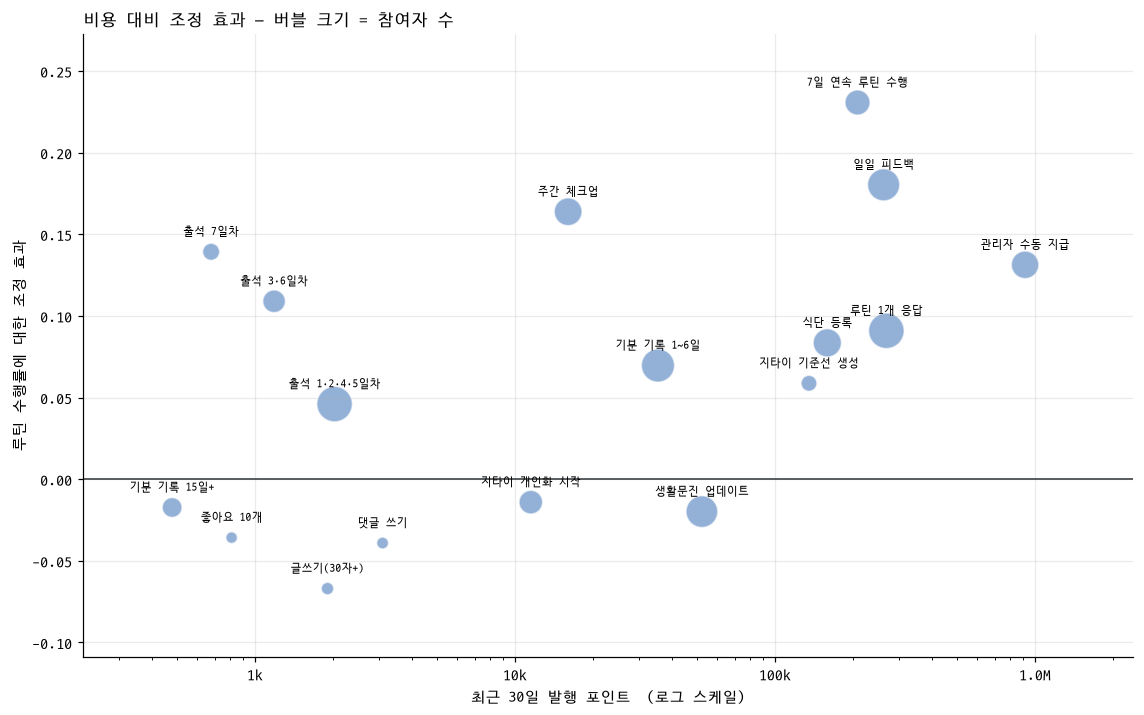

In [91]:
mat = (eff.merge(liability[["point_mission_no", "points_issued_30d"]], on="point_mission_no", how="left")
       .merge(overlap[["point_mission_no", "exclusive_earners", "exclusive_rate"]],
              on="point_mission_no", how="left"))
mat = mat[mat.points_issued_30d > 0]

fig, ax = plt.subplots(figsize=(10.5, 6.6))
ax.scatter(mat.points_issued_30d, mat.adj_coef,
           s=mat.n_joined * 2.2, alpha=0.55, color=C["issued"],
           edgecolor="white", linewidth=1)
for _, r in mat.iterrows():
    ax.annotate(r.label, (r.points_issued_30d, r.adj_coef),
                textcoords="offset points", xytext=(0, 11), ha="center", fontsize=7.5)
ax.set_xscale("log")
ax.axhline(0, color=C["dark"], lw=1)
ax.set_xlabel("최근 30일 발행 포인트  (로그 스케일)")
ax.set_ylabel("루틴 수행률에 대한 조정 효과")
ax.set_title("비용 대비 조정 효과 — 버블 크기 = 참여자 수", loc="left", fontsize=11)

# 라벨이 잘리지 않도록 양쪽에 여유를 준다
lo, hi = mat.points_issued_30d.min(), mat.points_issued_30d.max()
ax.set_xlim(lo / 2.2, hi * 2.6)
ax.margins(y=0.14)
ax.xaxis.set_major_formatter(mpl.ticker.FuncFormatter(
    lambda v, _: f"{v/1e6:.1f}M" if v >= 1e6 else (f"{v/1e3:.0f}k" if v >= 1000 else f"{v:.0f}")))

plt.show()

In [92]:
# 30일 발행액 기준 비용 효율: 조정 계수 1%p 당 포인트
mat["cost_per_effect"] = np.where(
    mat.adj_coef > 0, mat.points_issued_30d / (mat.adj_coef * 100), np.nan)

# 관리자 수동 지급은 미션이 아니라 재량 지급입니다. 1.3 에서 확인했듯 12주간 꾸준히 응답한
# 사용자에게 사후 지급한 보상이므로 인과가 반대로 흐른다(활동 → 포인트). 계수가 양수여도
# "효과 있는 미션"으로 읽으면 안 됩니다.
DISCRETIONARY = {101}

# 루틴 응답 자체에 포인트를 주는 미션. 성과 지표(루틴 수행률)와 같은 행동을 세므로
# 수치가 높게 나오는 것이 당연합니다 — 다른 미션과 같은 기준으로 판단하지 않습니다.
OUTCOME_OVERLAP = {35, 36, 37, 39}

verdict = []
for _, r in mat.iterrows():
    if r.point_mission_no in DISCRETIONARY:
        v = "통제 대상 — 재량 지급(인과 역전 의심)"
    elif r.point_mission_no in OUTCOME_OVERLAP:
        v = "판단보류 — 지급 조건이 성과 지표와 겹침"
    elif r.adj_coef > 0 and r.p_adj < 0.05:
        v = "유지"
    elif r.points_issued_30d >= 50_000:
        v = "축소 검토 — 고비용·효과 불명"
    else:
        v = "관망 — 저비용"
    verdict.append(v)
mat["판단"] = verdict

show(mat.sort_values("points_issued_30d", ascending=False)
     [["label", "points_issued_30d", "n_joined", "exclusive_earners",
       "adj_coef", "p_adj", "cost_per_effect", "판단"]],
     {"points_issued_30d": "{:,.0f}", "adj_coef": "{:+.3f}",
      "p_adj": "{:.2g}", "cost_per_effect": "{:,.0f}"})

미션,30일 발행,적립자,전속 적립자,조정 계수,p(조정),효과 1%p당 비용,판단
관리자 수동 지급,"915,000",147,1,+0.131,6.7e-07,"69,682",통제 대상 — 재량 지급(인과 역전 의심)
루틴 1개 응답,"267,915",246,2,+0.091,0.0097,"29,469",판단보류 — 지급 조건이 성과 지표와 겹침
일일 피드백,"261,500",201,0,+0.180,2e-10,"14,503",판단보류 — 지급 조건이 성과 지표와 겹침
7일 연속 루틴 수행,"207,500",122,0,+0.231,2.4e-16,"8,994",판단보류 — 지급 조건이 성과 지표와 겹침
식단 등록,"158,780",155,0,+0.084,0.00095,"19,014",유지
지타이 기준선 생성,"135,000",49,0,+0.059,0.063,"22,984",축소 검토 — 고비용·효과 불명
생활문진 업데이트,"52,300",196,7,-0.020,0.42,nan,축소 검토 — 고비용·효과 불명
기분 기록 1~6일,"35,450",214,1,+0.070,0.024,"5,091",유지
주간 체크업,"16,000",150,0,+0.164,2.1e-10,977,유지
지타이 개인화 시작,"11,500",108,0,-0.014,0.56,nan,관망 — 저비용


**표 읽는 법.** 가장 오른쪽 `판단` 열이 이 분석의 결론입니다. 다섯 가지로 나뉩니다.

| 판단 | 개수 | 뜻 |
|---|---|---|
| 유지 | 5 | 돈을 쓸 만한 근거가 확인됨 |
| 축소 검토 — 고비용·효과 불명 | 2 | 30일 5만P 이상 나가는데 효과가 확인되지 않음 |
| 관망 — 저비용 | 6 | 효과는 불분명하지만 금액이 작아 우선순위가 낮음 |
| 판단보류 — 지급 조건이 성과 지표와 겹침 | 3 | 포인트를 주는 조건이 곧 성과 지표라 이 방식으로 평가 불가 |
| 통제 대상 — 재량 지급 | 1 | 미션이 아니라 사람이 직접 지급한 것 |

`효과 1%p당 비용`은 루틴 수행률을 1%p 올리는 데 든 30일 포인트입니다. 작을수록 가성비가 좋습니다.
`출석 7일차`(49P)와 `출석 3·6일차`(109P)가 압도적으로 저렴하고, `관리자 수동 지급`(69,682P)이
가장 비쌉니다. 효과가 음수인 미션은 계산이 되지 않아 비어 있습니다.

**우선순위를 하나만 꼽으면 `축소 검토` 2개입니다.** `지타이 기준선 생성`(135,000P)과
`생활문진 업데이트`(52,300P)로, 합쳐서 30일에 18.7만P가 나가는데 루틴 수행률과의 연결은
확인되지 않았습니다.

---
## 7. 정리

In [93]:
lines = []
lines.append(f"[부채] 누적 발행 {issued:,.0f}P 중 {outstanding:,.0f}P({outstanding/issued:.0%})가 미상환 잔액으로 남아 있습니다.")
lines.append(f"[속도] 최근 30일 발행 {issued_30d:,.0f}P — 하루 {burn:,.0f}P, 연 환산 {burn*365:,.0f}P.")
lines.append(f"[집중] 발행 포인트의 80%를 상위 {n80}개 미션이 만듭니다. 30일 발행의 {top10:.0%}를 상위 10% 사용자가 가져갑니다.")
lines.append(f"[재량] 관리자 수동 지급이 30일 발행의 {admin.points_issued_30d/issued_30d:.0%}, 누적의 {admin.points_issued/issued:.0%}. "
             f"{peak:%Y-%m} 한 달에만 {a_peak:,.0f}P가 나갔고, 이를 빼면 그 달 발행은 전월의 {r_peak/prev:.1f}배에 그칩니다. "
             f"룰이 아니라 사람이 만드는 부채이므로 통제 대상 1순위입니다.")
lines.append(f"[수령자] 그 {recip.points_granted.sum():,.0f}P는 LOOP 사용자 {len(recip)}명에게 5,000P 정액 배치 2건으로 나갔습니다. "
             f"12주 응답 이력이 뚜렷한 집단(평균 {recip.weeks_answered_12w.mean():.1f}주 vs 미수령자 "
             f"{audit.loc[~audit.is_recipient,'weeks_answered_12w'].mean():.1f}주)이므로, "
             f"적립 이력이 0건인 미션 #41/#42(둘 다 5,000P)의 수기 대납으로 보입니다.")
lines.append(f"[역인과 확인] 관리자 수동 지급의 조정 계수가 양수로 나온 것은 미션 효과가 아니라 "
             f"'꾸준히 응답한 사람에게 사후 지급'한 구조 때문입니다. 4·6절에서 '유지' 판정에서 제외했습니다.")

live_dead_pts = catalog[catalog.point_mission_no.isin(live_dead.point_mission_no)].total_points.sum()
lines.append(f"[사문화] use_yn='Y'인데 30일간 적립 0건인 미션이 {len(live_dead)}개 (누적 발행 {live_dead_pts:,.0f}P).")

keep = mat[mat.판단 == "유지"]
cut  = mat[mat.판단 == "축소 검토 — 고비용·효과 불명"]
if len(keep):
    lines.append("[유지] 접속량 통제 후에도 루틴 수행률과 유의하게 연결된 미션: "
                 + ", ".join(f"{r.label}({r.adj_coef:+.3f})" for _, r in keep.iterrows()))
if len(cut):
    lines.append("[축소 검토] 30일 5만P 이상 발행하면서 조정 효과가 확인되지 않는 미션: "
                 + ", ".join(f"{r.label}({r.points_issued_30d:,.0f}P)" for _, r in cut.iterrows()))

solo_free = (overlap[(overlap.exclusive_earners == 0) & (overlap.points_issued_30d > 0)]
             .sort_values("points_issued_30d", ascending=False))
if len(solo_free):
    lines.append(f"[도달 중복] 전속 적립자가 0명인 미션 {len(solo_free)}개, 30일 발행 합계 "
                 f"{solo_free.points_issued_30d.sum():,.0f}P. 이 미션들을 없애도 '포인트를 받는 사용자'는 "
                 f"한 명도 줄지 않습니다 — 다만 해당 행동을 유도하는 유인은 함께 사라지므로 "
                 f"폐지 근거가 아니라 '금액 조정 여지'로 읽어야 합니다. 상위 5개: "
                 + ", ".join(f"{r.label}({r.points_issued_30d:,.0f}P)"
                             for _, r in solo_free.head(5).iterrows()))

for ln in lines:
    print(ln + "\n")

[부채] 누적 발행 8,224,195P 중 4,214,078P(51%)가 미상환 잔액으로 남아 있습니다.

[속도] 최근 30일 발행 2,120,382P — 하루 70,679P, 연 환산 25,797,981P.

[집중] 발행 포인트의 80%를 상위 6개 미션이 만듭니다. 30일 발행의 41%를 상위 10% 사용자가 가져갑니다.

[재량] 관리자 수동 지급이 30일 발행의 43%, 누적의 26%. 2026-07 한 달에만 2,115,000P가 나갔고, 이를 빼면 그 달 발행은 전월의 1.0배에 그칩니다. 룰이 아니라 사람이 만드는 부채이므로 통제 대상 1순위입니다.

[수령자] 그 2,115,000P는 LOOP 사용자 246명에게 5,000P 정액 배치 2건으로 나갔습니다. 12주 응답 이력이 뚜렷한 집단(평균 10.0주 vs 미수령자 1.5주)이므로, 적립 이력이 0건인 미션 #41/#42(둘 다 5,000P)의 수기 대납으로 보입니다.

[역인과 확인] 관리자 수동 지급의 조정 계수가 양수로 나온 것은 미션 효과가 아니라 '꾸준히 응답한 사람에게 사후 지급'한 구조 때문입니다. 4·6절에서 '유지' 판정에서 제외했습니다.

[사문화] use_yn='Y'인데 30일간 적립 0건인 미션이 10개 (누적 발행 46,700P).

[유지] 접속량 통제 후에도 루틴 수행률과 유의하게 연결된 미션: 주간 체크업(+0.164), 출석 7일차(+0.139), 출석 3·6일차(+0.109), 식단 등록(+0.084), 기분 기록 1~6일(+0.070)

[축소 검토] 30일 5만P 이상 발행하면서 조정 효과가 확인되지 않는 미션: 지타이 기준선 생성(135,000P), 생활문진 업데이트(52,300P)

[도달 중복] 전속 적립자가 0명인 미션 20개, 30일 발행 합계 820,594P. 이 미션들을 없애도 '포인트를 받는 사용자'는 한 명도 줄지 않습니다 — 다만 해당 행동을 유도하는 유인은 함께 사라지므로 폐지 근거가 아니라 '금액 조정 여지'로 읽어야 합니다. 상위 

### 한계

1. **단면 데이터입니다.** 조정 계수는 연관이지 인과가 아닙니다. 미션을 실제로 끄고 전후를 비교하는 것이 유일한 확인 방법입니다.
2. **통제 변수는 `visit_days_30d` 하나입니다.** 재직 기간·나이·JITAI 참여 여부 등을 더 넣으면 계수는 달라질 수 있습니다.
3. **루틴 응답에 직접 포인트를 주는 미션은 판단을 보류했습니다.** `루틴 1개 응답`·`7일 연속 루틴 수행`·`일일 피드백`은 포인트를 주는 조건과 성과 지표가 같은 행동이라, 이 방식으로는 가치를 평가할 수 없습니다. 별도의 지표(리텐션, 이탈률)가 필요합니다.
4. **상환율(`redemption_rate`)은 미션별로 해석하지 않았습니다.** 포인트 사용은 FIFO 로 오래된 lot 부터 소진되므로, 미션별 상환율은 그 미션의 발행 시점이 오래됐다는 뜻일 뿐입니다.
5. **30일은 짧습니다.** 주기가 긴 미션(친구 초대, 12주 완주)은 이 창에서 과소평가됩니다.